In [1]:
# ── 함수 설명 ──────────────────
# 회귀분석에 필요한 라이브러리를 불러오고, final_data.csv에서 독립변수(X)와 종속변수(y)를 준비하는 코드
import pandas as pd                  # 표(DataFrame) 형태로 데이터를 다루는 라이브러리
import numpy as np                   # 숫자/배열 계산을 위한 라이브러리
from sklearn.preprocessing import StandardScaler   # 데이터를 표준화(z-score)해주는 도구
from sklearn.linear_model import LinearRegression  # 선형회귀 모델을 만드는 도구
from statsmodels.stats.outliers_influence import variance_inflation_factor  # VIF(다중공선성) 계산 함수
import statsmodels.api as sm         # 회귀분석(OLS) 등 통계 모델을 만드는 라이브러리
import os                            # 폴더 경로 관련 기능을 제공하는 라이브러리
import matplotlib as plt             # 그래프 설정을 위한 라이브러리

os.chdir('/Users/ijaejun/Documents/sophomore_high/crime_catchers')
# os.chdir(경로): 작업 폴더를 지정한 경로로 옮김 → 어디서 실행해도 같은 파일을 찾을 수 있게 함


plt.rcParams['font.family'] = 'AppleGothic'
# rcParams['font.family'] = 'AppleGothic' : 그래프 글꼴을 맥용 한글 글꼴로 지정 → 한글이 깨지지 않게 함
plt.rcParams['axes.unicode_minus'] = False
# rcParams['axes.unicode_minus'] = False : 음수(-) 기호가 깨져 보이는 문제를 방지

df = pd.read_csv('data/processed/final_data.csv', encoding='utf-8-sig')
# read_csv(): CSV 파일을 표(DataFrame)로 읽어오는 함수
#   └ encoding='utf-8-sig' : 한글이 깨지지 않도록 인코딩 방식을 지정

# 독립변수 / 종속변수 설정 (인구수는 비율 변수 계산에만 사용되고 final_data.csv에는 없음)
feature_cols = ['실업률', '음주율', '물가상승률', '평균기온',
                '경찰1인당주민수', '기초수급비율(%)', '조이혼율', '지역소득', '외국인비율(%)']
# 회귀분석에 사용할 독립변수(원인이 되는 변수) 9개의 컬럼 이름 목록

X = df[feature_cols]
# df[feature_cols] : 독립변수 9개 컬럼만 선택해서 X(설명변수 표)로 만듦
y = df['범죄율']
# y : 종속변수(결과가 되는 변수) - 인구 10만 명당 범죄율

# 지역 더미변수 생성 (drop_first=True)
region_dummies = pd.get_dummies(df['지역'], prefix='지역', drop_first=True, dtype=int)
# get_dummies(): 글자(범주형) 값을 0/1 숫자 컬럼들로 바꿔주는 함수 (원-핫 인코딩)
#   └ df['지역'] : 변환할 대상은 '지역' 컬럼(6개 도시 이름)
#   └ prefix='지역' : 새로 생기는 컬럼 이름 앞에 '지역_'을 붙임 (예: 지역_부산)
#   └ drop_first=True : 첫 번째 도시(기준 도시)는 컬럼을 만들지 않음 → 다중공선성 방지
#   └ dtype=int : 결과값을 0/1 정수로 만듦

X = pd.concat([X, region_dummies], axis=1)
# concat(): 여러 개의 표를 옆으로(또는 위아래로) 이어붙이는 함수
#   └ [X, region_dummies] : 독립변수 표와 지역 더미변수 표를 이어붙임
#   └ axis=1 : 옆으로(가로, 컬럼 방향) 이어붙임


In [2]:
# ── 함수 설명 ──────────────────
# VIF(분산팽창계수, Variance Inflation Factor)로 변수들끼리 너무 비슷한지(다중공선성) 확인하고,
# VIF가 10 이상인 변수를 가장 큰 것부터 하나씩 제거하는 코드
# ── 1. VIF 계산 후 10 이상인 변수 단계적 제거 ──────────────────────────────
def calc_vif(X):
# def 함수이름(매개변수): : calc_vif라는 새 함수를 정의 (X라는 표를 입력받음)
    X_const = sm.add_constant(X)
    # add_constant(): 회귀분석에서 절편(상수항)을 계산하기 위해 모든 값이 1인 'const' 컬럼을 추가
    vif = pd.DataFrame()
    # DataFrame(): 결과를 담을 빈 표를 만듦
    vif['변수'] = X_const.columns
    # 표의 '변수' 컬럼에 X_const의 모든 컬럼 이름을 넣음
    vif['VIF'] = [variance_inflation_factor(X_const.values, i)
                   for i in range(X_const.shape[1])]
    # variance_inflation_factor(데이터, i): i번째 변수가 다른 변수들로 얼마나 잘 설명되는지를 수치(VIF)로 계산
    #   └ VIF가 클수록 그 변수가 다른 변수와 비슷한 정보를 담고 있다는 뜻(다중공선성 높음)
    # [... for i in range(...)] : 리스트 컴프리헨션으로 모든 컬럼에 대해 VIF를 계산해 리스트로 만듦
    return vif[vif['변수'] != 'const'].reset_index(drop=True)
    # vif[vif['변수'] != 'const'] : 절편(const) 행은 제외하고 실제 변수들만 남김
    # reset_index(drop=True) : 행 번호를 0부터 다시 매김

X_selected = X.copy()
# copy(): X를 복사해서 원본을 건드리지 않고 변수를 제거해 나갈 새 표를 만듦
step = 1
# 반복 단계를 표시하기 위한 변수 (1부터 시작)

while True:
# while True: : 조건이 만족될 때까지(break가 나올 때까지) 계속 반복하는 무한 루프
    vif_data = calc_vif(X_selected).sort_values('VIF', ascending=False)
    # calc_vif(X_selected) : 현재 남은 변수들의 VIF를 계산
    # sort_values('VIF', ascending=False) : VIF가 큰 변수부터 순서대로 정렬
    print(f"📊 Step {step} VIF 결과:")
    print(vif_data.to_string(index=False))
    # to_string(index=False): 표를 출력할 때 행 번호(인덱스)는 표시하지 않음

    max_row = vif_data.iloc[0]
    # iloc[0] : 정렬된 표에서 VIF가 가장 큰 첫 번째 행을 가져옴
    if max_row['VIF'] >= 10:
    # if 조건문: 가장 큰 VIF가 10 이상이면(다중공선성이 심하면) 그 변수를 제거
        drop_var = max_row['변수']
        print(f"⚠️ VIF {max_row['VIF']:.2f} ≥ 10 → '{drop_var}' 제거\n")
        X_selected = X_selected.drop(columns=[drop_var])
        # drop(columns=[drop_var]) : VIF가 가장 큰 변수를 표에서 제거
        step += 1
        # step += 1 : 다음 단계로 넘어가기 위해 1을 더함
    else:
        print("\n✅ 모든 변수 VIF < 10 → 제거 종료")
        break
        # break : 모든 변수의 VIF가 10보다 작아지면 반복을 멈춤


📊 Step 1 VIF 결과:
       변수        VIF
    지역_울산 111.470465
     지역소득 104.637625
기초수급비율(%)  33.517264
    지역_인천  32.043515
     평균기온  20.707822
 경찰1인당주민수  15.976501
 외국인비율(%)  14.889123
     조이혼율  14.887076
    지역_부산   6.328157
    지역_대전   5.197346
    물가상승률   4.861585
      실업률   4.168197
      음주율   3.648693
    지역_대구   3.140914
⚠️ VIF 111.47 ≥ 10 → '지역_울산' 제거

📊 Step 2 VIF 결과:
       변수       VIF
    지역_인천 30.035367
기초수급비율(%) 28.858195
     평균기온 20.673238
 경찰1인당주민수 15.231808
     조이혼율 14.368109
     지역소득 13.904412
 외국인비율(%) 13.752128
    지역_부산  6.252000
    물가상승률  4.677555
      실업률  3.967033
      음주율  3.385689
    지역_대전  3.099743
    지역_대구  2.912107
⚠️ VIF 30.04 ≥ 10 → '지역_인천' 제거

📊 Step 3 VIF 결과:
       변수       VIF
기초수급비율(%) 23.340569
     지역소득 13.836743
 경찰1인당주민수 13.817741
     평균기온 12.515593
     조이혼율 11.542878
 외국인비율(%)  8.489871
    지역_부산  4.948057
    물가상승률  4.553543
      실업률  3.668447
      음주율  3.368965
    지역_대전  2.740790
    지역_대구  2.656576
⚠️ VIF 23.34 ≥ 10 → '기초수급비율(%

In [3]:
# ── 함수 설명 ──────────────────
# VIF 검사를 통과한 변수들로 다중 선형회귀분석(OLS)을 실행하고 결과를 출력하는 코드
# ── 2. 최종 변수로 OLS 다중 선형회귀분석 ──────────────────────────────
X_final = sm.add_constant(X_selected)
# add_constant(): 절편(상수항)을 추정하기 위해 모든 값이 1인 'const' 컬럼을 추가

model = sm.OLS(y, X_final).fit()
# OLS(y, X_final): 최소제곱법(Ordinary Least Squares)으로 y를 X_final의 변수들로 설명하는 회귀모델을 만듦
#   └ y : 종속변수(범죄율)
#   └ X_final : 독립변수 + 절편(const)
# fit(): 데이터에 맞게 모델을 학습(추정)시켜 회귀계수를 계산

print(model.summary())
# summary(): 회귀분석 결과(R², 회귀계수, 표준오차, p-value 등)를 표 형태로 보여주는 함수


                            OLS Regression Results                            
Dep. Variable:                    범죄율   R-squared:                       0.768
Model:                            OLS   Adj. R-squared:                  0.726
Method:                 Least Squares   F-statistic:                     18.21
Date:                Mon, 15 Jun 2026   Prob (F-statistic):           4.33e-14
Time:                        10:50:33   Log-Likelihood:                -355.74
No. Observations:                  66   AIC:                             733.5
Df Residuals:                      55   BIC:                             757.6
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        244.3298    161.426      1.514      0.1

In [4]:
# ── 함수 설명 ──────────────────
# 회귀분석 결과(R², 변수 목록)를 정리해서 보여주고, 표준화 계수로 가장 영향력 큰 변수 Top 3을 찾는 코드
# ── 3. 결과 정리 ──────────────────────────────
print("✅ 최종 선택된 변수:")
print(X_selected.columns.tolist())
# tolist(): 컬럼 이름들을 파이썬 리스트 형태로 변환해서 출력

print(f"\n✅ R-squared: {model.rsquared:.4f}")
# rsquared : 모델이 종속변수(범죄율)의 변동을 얼마나 설명하는지 나타내는 값 (0~1, 1에 가까울수록 설명력 높음)
print(f"✅ Adj. R-squared: {model.rsquared_adj:.4f}")
# rsquared_adj : 변수 개수가 많아질수록 R²가 무조건 커지는 것을 보정한 값
print(f"✅ F-statistic p-value: {model.f_pvalue:.4e}")
# f_pvalue : 모델 전체가 통계적으로 의미가 있는지(우연이 아닌지) 판단하는 값 (작을수록 의미 있음)

# 표준화 회귀계수로 영향력 비교 (단위 차이를 보정)
beta = model.params.drop('const')
# params : 회귀분석으로 추정된 각 변수의 계수(coefficient)
# drop('const') : 절편(상수항)은 제외하고 변수들의 계수만 남김

std_coef = (beta * X_selected.std() / y.std()).abs().sort_values(ascending=False)
# beta * X_selected.std() / y.std() : 회귀계수에 (X의 표준편차/y의 표준편차)를 곱해 단위를 통일한 '표준화 계수'를 계산
#   └ 단위가 서로 다른 변수들(예: 지역소득 vs 실업률)의 영향력을 같은 기준으로 비교할 수 있게 해줌
# abs(): 절댓값으로 바꿔서 영향력의 '크기'만 비교 (부호는 무시)
# sort_values(ascending=False): 영향력이 큰 변수부터 순서대로 정렬

print("\n🏆 영향력 큰 변수 Top 3 (표준화 계수 기준):")
for i, (var, val) in enumerate(std_coef.head(3).items(), 1):
# enumerate(리스트, 1): 리스트의 각 항목에 1부터 시작하는 순서 번호(i)를 함께 붙여줌
# head(3): 상위 3개만 선택
# items(): (변수이름, 값) 쌍을 하나씩 꺼냄
    print(f"{i}. {var}  (표준화 계수: {val:.4f}, 회귀계수: {model.params[var]:.4f}, p-value: {model.pvalues[var]:.4f})")
    # pvalues : 각 변수의 회귀계수가 통계적으로 의미 있는지(0.05보다 작으면 유의함) 보여주는 값
print(model.summary())
# summary(): 회귀분석 전체 결과를 다시 한 번 표로 출력


✅ 최종 선택된 변수:
['실업률', '음주율', '물가상승률', '경찰1인당주민수', '조이혼율', '지역소득', '외국인비율(%)', '지역_대구', '지역_대전', '지역_부산']

✅ R-squared: 0.7680
✅ Adj. R-squared: 0.7259
✅ F-statistic p-value: 4.3266e-14

🏆 영향력 큰 변수 Top 3 (표준화 계수 기준):
1. 실업률  (표준화 계수: 0.5906, 회귀계수: -105.9049, p-value: 0.0000)
2. 지역소득  (표준화 계수: 0.4259, 회귀계수: -0.0030, p-value: 0.0000)
3. 물가상승률  (표준화 계수: 0.3178, 회귀계수: -24.7685, p-value: 0.0008)
                            OLS Regression Results                            
Dep. Variable:                    범죄율   R-squared:                       0.768
Model:                            OLS   Adj. R-squared:                  0.726
Method:                 Least Squares   F-statistic:                     18.21
Date:                Mon, 15 Jun 2026   Prob (F-statistic):           4.33e-14
Time:                        10:50:33   Log-Likelihood:                -355.74
No. Observations:                  66   AIC:                             733.5
Df Residuals:                      55   BIC:           

## 4. 데이터 및 회귀결과 검증

In [5]:
# ── 함수 설명 ──────────────────
# 데이터의 행 개수, 결측치, 연도별 범죄율 평균을 확인하고 2018년 전후 변화를 비교하는 코드
# ── 4-1. 데이터 검증 ──────────────────────────────
print(f"데이터 shape: {df.shape}  (기대값: 6개 도시 × 11개 연도 = {6*11}행)")
# shape : (행 개수, 열 개수)를 알려주는 속성 → 66행인지 확인

print("\n도시별 관측 연도 수:")
print(df.groupby('지역')['연도'].count())
# groupby('지역'): '지역'별로 데이터를 묶음
# ['연도'].count(): 각 지역에 연도가 몇 개씩 있는지(=관측치 개수) 셈 → 모두 11이어야 정상

print(f"\n결측치 총 개수: {df.isnull().sum().sum()}개")
# isnull().sum().sum() : 컬럼별 결측치 개수를 구한 뒤(첫 sum) 전체 합계를 구함(둘째 sum)

print("\n연도별 범죄율 평균:")
print(df.groupby('연도')['범죄율'].mean().round(2))
# groupby('연도')['범죄율'].mean(): 연도별 범죄율 평균을 계산
# round(2): 소수점 둘째 자리까지 표시

# 2018년 전후 비교
before = df[df['연도'] < 2018]['범죄율']
# df[df['연도'] < 2018] : '연도'가 2018보다 작은(2014~2017) 행만 선택
after = df[df['연도'] >= 2018]['범죄율']
# df[df['연도'] >= 2018] : '연도'가 2018 이상(2018~2024)인 행만 선택
diff = after.mean() - before.mean()
# mean(): 각 그룹의 평균 범죄율을 계산하고, 두 평균의 차이를 구함

print(f"\n2018년 이전(2014~2017, n={len(before)}) 평균 범죄율: {before.mean():.2f}")
print(f"2018년 이후(2018~2024, n={len(after)}) 평균 범죄율: {after.mean():.2f}")
print(f"차이: {diff:.2f}  (변화율 {diff/before.mean()*100:.1f}%)")
# diff/before.mean()*100 : (이후-이전)/이전 × 100 → 변화율(%)을 계산


데이터 shape: (66, 12)  (기대값: 6개 도시 × 11개 연도 = 66행)

도시별 관측 연도 수:
지역
광주    11
대구    11
대전    11
부산    11
울산    11
인천    11
Name: 연도, dtype: int64

결측치 총 개수: 0개

연도별 범죄율 평균:
연도
2014    860.56
2015    841.48
2016    748.67
2017    701.97
2018    695.51
2019    699.92
2020    647.15
2021    589.91
2022    633.77
2023    646.85
2024    638.94
Name: 범죄율, dtype: float64

2018년 이전(2014~2017, n=24) 평균 범죄율: 788.17
2018년 이후(2018~2024, n=42) 평균 범죄율: 650.29
차이: -137.87  (변화율 -17.5%)


In [6]:
# ── 함수 설명 ──────────────────
# 범죄이론에서 예상하는 변수별 영향 방향(+/-)과 실제 회귀분석 결과의 방향이 일치하는지 비교하고,
# 통계적으로 유의하지 않은(p≥0.05) 변수를 찾아내는 코드
# ── 4-2. 회귀계수 부호 및 통계적 유의성 검토 ──────────────────────────────
# 범죄이론상 기대되는 부호 ('?'는 이론적으로 방향이 정해지지 않은 변수)
expected_sign = {
    '실업률': '+',          # 실업률↑ → 범죄율↑ 예상 (긴장이론)
    '음주율': '+',          # 음주율↑ → 범죄율↑ 예상
    '물가상승률': '?',       # 경제적 압박이론(+) vs 안정적 성장기 동반 상승(-) 등 선행연구마다 방향이 다름
    '경찰1인당주민수': '+',   # 경찰 1인당 담당주민↑(치안인력 부족) → 범죄율↑ 예상
    '조이혼율': '+',         # 가정해체↑ → 범죄율↑ 예상
    '지역소득': '?',         # 박탈이론(-) vs 기회이론(+) 상충
    '외국인비율(%)': '?',    # 선행연구에서도 방향 일관되지 않음
}
# 딕셔너리(dict): {key: value} 형태로 변수 이름과 기대되는 부호('+', '-', '?')를 짝지어 저장

print(f"{'변수':<12} {'회귀계수':>12} {'기대부호':^8} {'실제부호':^8} {'일치':^6} {'p-value':>8}")
# f-string 안의 {값:<12}, {값:>12}, {값:^8} : 문자열을 각각 왼쪽/오른쪽/가운데 정렬하면서 자릿수를 맞춤
print("-" * 60)
# "-" * 60 : '-' 문자를 60번 반복해서 구분선을 만듦

for var in X_selected.columns:
# for문: 최종 선택된 변수 이름을 하나씩 var에 담아 반복
    coef = model.params[var]
    # model.params[var] : 해당 변수의 회귀계수(영향의 크기와 방향) 값
    pval = model.pvalues[var]
    # model.pvalues[var] : 해당 변수의 p-value(통계적으로 의미가 있는지 보여주는 값)
    exp = expected_sign.get(var, '?')
    # dict.get(key, 기본값) : expected_sign에 var가 있으면 그 값을, 없으면 '?'를 반환
    actual = '+' if coef > 0 else '-'
    # 조건부 표현식: coef가 0보다 크면 '+', 아니면 '-'를 actual에 저장
    mark = "✅" if (exp == '?' or exp == actual) else "❌"
    # 기대부호가 '?'(상관없음)이거나 실제부호와 같으면 ✅, 다르면 ❌
    print(f"{var:<12} {coef:>12.4f} {exp:^8} {actual:^8} {mark:^6} {pval:>8.4f}")

print("\n⚠️ p-value ≥ 0.05 (통계적으로 유의하지 않은 변수):")
insig = model.pvalues[model.pvalues >= 0.05].drop('const', errors='ignore')
# model.pvalues[model.pvalues >= 0.05] : p-value가 0.05 이상인 변수만 선택 (유의하지 않은 변수)
# drop('const', errors='ignore') : 절편(const)은 제외, 만약 없어도 에러 내지 않음
print(insig if len(insig) else "없음")
# 조건부 표현식: insig에 변수가 있으면 그 목록을, 없으면 "없음"을 출력


변수                   회귀계수   기대부호     실제부호     일치    p-value
------------------------------------------------------------
실업률             -105.9049    +        -       ❌      0.0000
음주율                9.9457    +        +       ✅      0.0037
물가상승률            -24.7685    ?        -       ✅      0.0008
경찰1인당주민수           0.6562    +        +       ✅      0.1235
조이혼율              94.3132    +        +       ✅      0.2063
지역소득              -0.0030    ?        -       ✅      0.0000
외국인비율(%)         -50.5743    ?        -       ✅      0.0466
지역_대구            -24.1394    ?        -       ✅      0.4312
지역_대전              0.2681    ?        +       ✅      0.9927
지역_부산             62.1095    ?        +       ✅      0.1096

⚠️ p-value ≥ 0.05 (통계적으로 유의하지 않은 변수):
경찰1인당주민수    0.123537
조이혼율        0.206315
지역_대구       0.431159
지역_대전       0.992690
지역_부산       0.109640
dtype: float64


Shapiro-Wilk 검정: 통계량=0.9448, p-value=0.0054
→ 정규성 가정 위배 (p < 0.05)

Durbin-Watson: 1.3280  (2에 가까울수록 자기상관 없음, 1.5 미만이면 양의 자기상관 의심)
Breusch-Pagan(이분산성) p-value: 0.0882

최대 잔차 관측치: 광주 2014년 (실제 1108.8, 예측 893.2, 잔차 215.5)


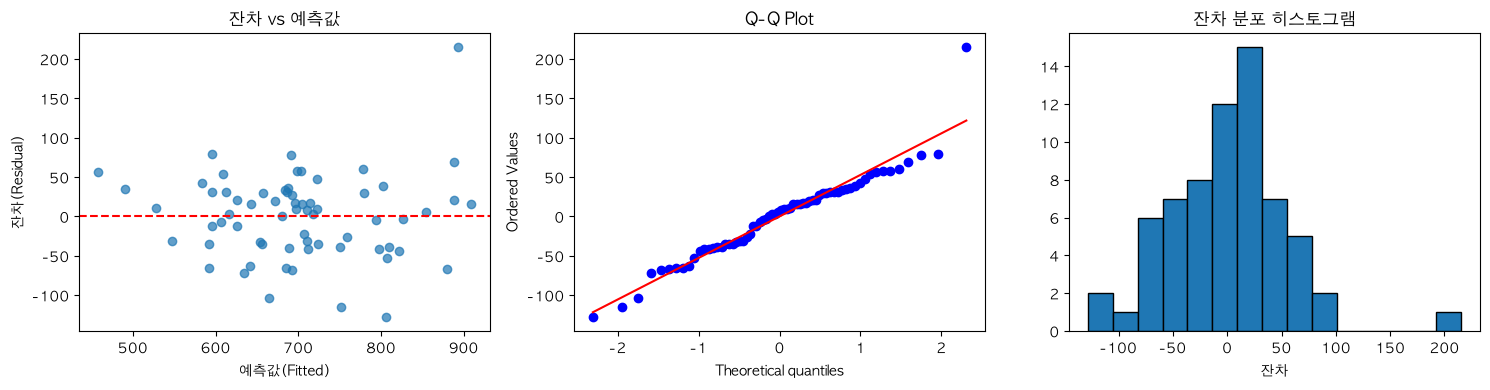

In [7]:
# ── 함수 설명 ──────────────────
# 회귀분석의 잔차(실제값-예측값)가 정규분포를 따르는지, 자기상관/이분산성이 있는지 검정하고
# 잔차를 그래프 3개(산점도, Q-Q Plot, 히스토그램)로 시각화하는 코드
# ── 4-3. 잔차 정규성 / 자기상관 / 이분산성 검정 및 시각화 ──────────────────────────────
import matplotlib.pyplot as plt   # 그래프를 그리는 라이브러리
from scipy import stats           # 통계 검정(Shapiro-Wilk, Q-Q Plot 등)을 위한 라이브러리
from statsmodels.stats.stattools import durbin_watson  # 자기상관 검정 함수
from statsmodels.stats.diagnostic import het_breuschpagan  # 이분산성 검정 함수

resid = model.resid
# resid : 회귀모델의 잔차(실제 범죄율 - 예측 범죄율) 값들
fitted = model.fittedvalues
# fittedvalues : 회귀모델이 예측한 값들

# Shapiro-Wilk 정규성 검정
shapiro_stat, shapiro_p = stats.shapiro(resid)
# shapiro(resid): 잔차가 정규분포를 따르는지 검정하는 함수
#   └ 통계량(shapiro_stat)과 p-value(shapiro_p)를 함께 반환
print(f"Shapiro-Wilk 검정: 통계량={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")
print("→", "정규성 가정 충족 (p ≥ 0.05)" if shapiro_p >= 0.05 else "정규성 가정 위배 (p < 0.05)")
# 조건부 표현식: p-value가 0.05 이상이면 "정규성 충족", 아니면 "위배"를 출력

# Durbin-Watson (자기상관)
dw = durbin_watson(resid)
# durbin_watson(resid): 잔차들이 순서대로 비슷하게 움직이는 정도(자기상관)를 0~4 사이 값으로 계산
#   └ 2에 가까울수록 자기상관이 없음, 0에 가까우면 양의 자기상관 의심
print(f"\nDurbin-Watson: {dw:.4f}  (2에 가까울수록 자기상관 없음, 1.5 미만이면 양의 자기상관 의심)")

# Breusch-Pagan (이분산성)
bp_p = het_breuschpagan(resid, X_final)[1]
# het_breuschpagan(잔차, X): 잔차의 흩어진 정도(분산)가 독립변수에 따라 일정한지 검정
#   └ 반환값 중 두 번째([1])가 p-value
print(f"Breusch-Pagan(이분산성) p-value: {bp_p:.4f}")

# 가장 큰 잔차를 가진 관측치
max_idx = resid.abs().idxmax()
# abs(): 잔차를 절댓값으로 변환 (음수도 크기로 비교하기 위해)
# idxmax(): 값이 가장 큰 행의 인덱스(번호)를 반환
print(f"\n최대 잔차 관측치: {df.loc[max_idx, '지역']} {df.loc[max_idx, '연도']}년 "
      f"(실제 {y[max_idx]:.1f}, 예측 {fitted[max_idx]:.1f}, 잔차 {resid[max_idx]:.1f})")
# df.loc[max_idx, '지역'] : 인덱스가 max_idx인 행의 '지역' 값을 가져옴

# 잔차 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# subplots(1, 3): 1행 3열, 즉 그래프 3개를 가로로 나란히 배치할 도화지를 만듦
#   └ figsize=(15, 4) : 전체 크기를 가로 15, 세로 4(인치)로 지정
#   └ fig : 전체 도화지, axes : 그래프 3개가 들어있는 배열

axes[0].scatter(fitted, resid, alpha=0.7)
# scatter(): 점으로 흩어진 산점도를 그림 (x=예측값, y=잔차)
#   └ alpha=0.7 : 점의 투명도를 70%로 설정 (점이 겹쳐도 보기 편하게)
axes[0].axhline(0, color='red', linestyle='--')
# axhline(0): y=0 위치에 가로선을 그림 (잔차가 0에서 얼마나 떨어져 있는지 기준선)
#   └ color='red' : 선 색을 빨강으로
#   └ linestyle='--' : 점선으로 표시
axes[0].set_xlabel('예측값(Fitted)')
axes[0].set_ylabel('잔차(Residual)')
axes[0].set_title('잔차 vs 예측값')

stats.probplot(resid, dist='norm', plot=axes[1])
# probplot(): 잔차가 정규분포와 얼마나 비슷한지 점으로 비교하는 Q-Q 플롯을 그림
#   └ dist='norm' : 비교 대상 분포로 정규분포(norm)를 사용
#   └ plot=axes[1] : 그림을 그릴 위치(두 번째 칸)를 지정
axes[1].set_title('Q-Q Plot')

axes[2].hist(resid, bins=15, edgecolor='black')
# hist(): 잔차 값들의 분포를 히스토그램으로 그림
#   └ bins=15 : 값의 구간을 15개로 나눔
#   └ edgecolor='black' : 막대 테두리를 검은색으로 표시
axes[2].set_title('잔차 분포 히스토그램')
axes[2].set_xlabel('잔차')

plt.tight_layout()
# tight_layout(): 3개 그래프가 겹치지 않도록 여백을 자동으로 맞춤
plt.savefig('visualizations/residual_diagnostics.png', dpi=150)
# savefig(): 그래프를 이미지 파일로 저장 (dpi=150: 해상도 지정)
plt.show()
# show(): 완성된 그래프들을 화면에 출력


In [8]:
# ── 함수 설명 ──────────────────
# Condition Number(변수 간 크기 차이가 너무 크면 커지는 값)를 계산하고,
# 표준화 전/후를 비교해서 진짜 다중공선성 문제인지 단위(스케일) 차이 때문인지 확인하는 코드
# 표본 수 대비 변수 수의 비율도 함께 점검한다.
# ── 4-4. Condition Number 및 표본 대 변수 비율 진단 ──────────────────────────────
print(f"원본 변수 기준 Condition Number: {model.condition_number:,.0f}")
# condition_number : 변수들 사이의 크기(스케일) 차이나 다중공선성이 클수록 커지는 값
#   └ {:,.0f} : 숫자를 천 단위 구분 기호(,)와 함께 정수로 표시

# 변수를 표준화했을 때의 Condition Number (스케일 문제인지 다중공선성 문제인지 구분)
X_std = (X_selected - X_selected.mean()) / X_selected.std()
# (값 - 평균) / 표준편차 : z-score 표준화 → 모든 변수를 평균 0, 표준편차 1로 맞춤
model_std = sm.OLS(y, sm.add_constant(X_std)).fit()
# 표준화된 변수로 다시 회귀분석을 실행
print(f"표준화 후 Condition Number: {model_std.condition_number:.2f}")
# 표준화 후에도 Condition Number가 크면 진짜 다중공선성 문제, 작아지면 단위 차이 때문이었다는 뜻

print("\n변수별 스케일(평균 / 표준편차):")
print(X_selected.agg(['mean', 'std']).T.round(3))
# agg(['mean','std']): 각 컬럼의 평균과 표준편차를 한 번에 계산
# .T : 행과 열을 바꿔서(transpose) 변수 이름이 행으로 오도록 표시
# round(3): 소수점 셋째 자리까지 표시

print(f"\n표본 수(n) = {len(y)}, 추정 파라미터 수(상수 포함) = {X_final.shape[1]}")
# len(y) : 전체 데이터 행 개수(표본 수)
# X_final.shape[1] : X_final의 컬럼 개수(추정해야 하는 계수 개수, 상수 포함)
print(f"표본 대 변수 비율 = {len(y) / X_final.shape[1]:.1f}  (권장 기준: 10 이상)")
# 표본 수를 변수 개수로 나눠서, 변수 1개당 데이터가 충분한지 확인 (10 이상이면 안정적)


원본 변수 기준 Condition Number: 901,601
표준화 후 Condition Number: 6.90

변수별 스케일(평균 / 표준편차):
               mean        std
실업률           3.641      0.619
음주율          59.911      3.208
물가상승률         1.862      1.424
경찰1인당주민수    439.258     48.323
조이혼율          1.977      0.251
지역소득      36508.409  15818.215
외국인비율(%)      1.583      0.471
지역_대구         0.167      0.376
지역_대전         0.167      0.376
지역_부산         0.167      0.376

표본 수(n) = 66, 추정 파라미터 수(상수 포함) = 11
표본 대 변수 비율 = 6.0  (권장 기준: 10 이상)


In [9]:
# ── 함수 설명 ──────────────────
# 코로나19 시기(2020~2021)와 그 외 시기의 음주율·범죄율·잔차 평균을 비교해서,
# 코로나19가 데이터에 어떤 영향을 미쳤는지 확인하는 코드
# ── 4-5. 코로나19 시기(2020~2021) 영향 확인 ──────────────────────────────
# README 방침: 2020~2021년은 이상치로 제거하지 않고 분석에 포함하되, 해석 시 영향을 별도 언급
covid_years = [2020, 2021]
# 코로나19로 인해 사회적 거리두기가 시행된 연도 목록

non_covid = df[~df['연도'].isin(covid_years)]
# isin(covid_years) : '연도'가 covid_years 목록에 포함되는지 True/False로 표시
# ~ : True/False를 반대로 뒤집음 (not) → 코로나 연도가 아닌 행만 선택
covid_df = df[df['연도'].isin(covid_years)]
# 코로나 연도(2020, 2021)에 해당하는 행만 선택

print("연도별 음주율·범죄율 평균:")
print(df.groupby('연도')[['음주율', '범죄율']].mean().round(2))
# groupby('연도')[['음주율','범죄율']].mean(): 연도별로 음주율과 범죄율의 평균을 계산

compare = pd.DataFrame({
    '비코로나 평균(09개년)': non_covid[['음주율', '범죄율']].mean(),
    '코로나 평균(20~21)': covid_df[['음주율', '범죄율']].mean(),
})
# DataFrame({열이름: 값, ...}) : 두 그룹(비코로나/코로나)의 평균값을 담은 새 표를 만듦

compare['차이'] = compare['코로나 평균(20~21)'] - compare['비코로나 평균(09개년)']
# 새 컬럼 '차이' = 코로나 시기 평균 - 비코로나 시기 평균
compare['변화율(%)'] = (compare['차이'] / compare['비코로나 평균(09개년)'] * 100).round(2)
# 변화율(%) = (차이 / 비코로나 평균) × 100, round(2)로 소수점 둘째 자리까지 표시

print("\n코로나 시기 vs 그 외 시기 비교:")
print(compare.round(2))

# 회귀모형 잔차에서도 코로나 시기 패턴이 다른지 확인
resid_by_year = pd.Series(resid.values, index=df['연도']).groupby(level=0).mean()
# pd.Series(resid.values, index=df['연도']) : 잔차 값에 '연도'를 인덱스로 붙여 시리즈(목록)를 만듦
# groupby(level=0): 인덱스(연도) 기준으로 그룹을 묶음
# mean(): 연도별 잔차 평균을 계산

print("\n연도별 평균 잔차:")
print(resid_by_year.round(2))
print(f"\n코로나 시기(2020~2021) 평균 잔차: {resid_by_year.loc[covid_years].mean():.2f}")
# loc[covid_years] : 인덱스가 2020, 2021인 값들만 선택해서 평균을 구함
print(f"그 외 시기 평균 잔차: {resid_by_year.drop(covid_years).mean():.2f}")
# drop(covid_years) : 2020, 2021을 제외한 나머지 연도들의 평균을 구함

print("""
⚠️ 코로나19 영향 메모:
- 2020~2021년에 음주율(-10.6%)과 범죄율(-13.9%)이 다른 연도 대비 동시에 크게 하락함
  → 사회적 거리두기·유흥업소 영업제한 등 일시적 외부 충격의 영향일 가능성이 큼
- README 방침에 따라 해당 연도를 제거하지 않고 분석에 포함했으나,
  이 시기의 변수 간 관계가 '평상시' 패턴과 다를 수 있어 회귀계수 추정에 일부 영향을 줄 수 있음
""")
# print("""...""") : 여러 줄짜리 문자열(메모)을 한 번에 출력


연도별 음주율·범죄율 평균:
        음주율     범죄율
연도                 
2014  62.05  860.56
2015  62.35  841.48
2016  61.85  748.67
2017  62.55  701.97
2018  62.12  695.51
2019  60.75  699.92
2020  54.87  647.15
2021  54.40  589.91
2022  58.63  633.77
2023  59.48  646.85
2024  59.97  638.94

코로나 시기 vs 그 외 시기 비교:
     비코로나 평균(09개년)  코로나 평균(20~21)      차이  변화율(%)
음주율          61.08          54.63   -6.45  -10.56
범죄율         718.63         618.53 -100.10  -13.93

연도별 평균 잔차:
연도
2014    24.61
2015    33.63
2016   -16.36
2017   -32.52
2018     0.30
2019   -23.12
2020    15.51
2021   -21.84
2022     9.57
2023     0.66
2024     9.55
dtype: float64

코로나 시기(2020~2021) 평균 잔차: -3.16
그 외 시기 평균 잔차: 0.70

⚠️ 코로나19 영향 메모:
- 2020~2021년에 음주율(-10.6%)과 범죄율(-13.9%)이 다른 연도 대비 동시에 크게 하락함
  → 사회적 거리두기·유흥업소 영업제한 등 일시적 외부 충격의 영향일 가능성이 큼
- README 방침에 따라 해당 연도를 제거하지 않고 분석에 포함했으나,
  이 시기의 변수 간 관계가 '평상시' 패턴과 다를 수 있어 회귀계수 추정에 일부 영향을 줄 수 있음



## 5. 종합 검토 결과

### 데이터 검증
- 66행 = 6개 도시 × 11개 연도(2014~2024), 결측치 없음 ✅
- 2018년 이전(2014~2017) 평균 788.17 → 이후(2018~2024) 평균 650.29로 약 -17.5% 감소
- 다만 연도별 평균을 보면 2018년 시점에서 갑자기 끊기는 '불연속'은 아니며, **2014~2021년까지 완만한 하락세 + 2020~2021년 코로나19 시기 추가 하락 + 2022년 이후 소폭 반등**의 추세에 가까움. "2018년 전후 차이"는 추세적 하락의 일부를 절단한 결과로 해석하는 것이 적절함

### 회귀계수 부호 검토
- ❌ **실업률**: 이론(긴장이론)상 (+) 기대되지만 결과는 **-105.9 (p<0.001)** → 가장 우려되는 부호 불일치
- ✅ 음주율(+9.95), 경찰1인당주민수(+0.656), 조이혼율(+94.3): 부호는 이론과 일치하나, 뒤 2개는 p≥0.05로 통계적 유의성 부족
- 물가상승률(-24.8), 지역소득(-0.003), 외국인비율(-50.6): 이론적으로 부호가 사전에 정해진 변수가 아니므로 음수 자체가 "오류"는 아님. 특히 외국인비율의 음수는 통념과 다르지만 다수 실증연구 결과와는 부합

### 통계적으로 유의하지 않은 변수 (p ≥ 0.05)
- 경찰1인당주민수(0.124), 조이혼율(0.206), 지역_대구(0.431), 지역_대전(0.993), 지역_부산(0.110), const(0.136)
- 10개 설명변수 중 5개가 개별적으로는 유의하지 않음

### 잔차 진단
- **Shapiro-Wilk p=0.0054 → 정규성 위배**. 광주 2014년 관측치(잔차 +215.5, 실제 1108.76)가 강한 이상치로 작용해 우측 꼬리를 만듦
- **Durbin-Watson=1.328** → 2보다 작아 양의 자기상관 가능성. 동일 도시가 11개 연도에 걸쳐 반복 관측된 패널 구조를 단순 OLS로 처리해 독립성 가정이 깨졌을 가능성이 큼
- Breusch-Pagan p=0.088 → 5% 수준에서 이분산성이 통계적으로 기각되지는 않으나 경계선에 가까움

### 모델 적합성
- **R²=0.768, Adj. R²=0.726**은 표본 수(66) 대비 변수 수(10+상수=11)가 많아 표본/변수 비율이 6.0(권장 10 이상)에 못 미침 → R²가 다소 과대평가되었을 가능성, 보수적으로 해석 필요
- **Condition Number=901,600**은 지역소득(평균 36,508)처럼 단위(스케일)가 큰 변수와 실업률(평균 3.6) 같은 변수가 함께 있어 발생한 **수치적 인공물**에 가까움. 변수를 표준화하면 Condition Number가 6.9로 떨어져 실제 다중공선성 문제(VIF<10으로 이미 확인)와는 별개임

### 개선 제안
1. 패널데이터 회귀(도시·연도 고정효과 또는 클러스터 표준오차)로 전환 → 자기상관·도시별 이질성 통제
2. 회귀 전 변수 표준화 또는 로그변환(지역소득, 인구수 등 스케일 큰 변수) → Condition Number 개선 및 계수 해석 용이
3. 광주 2014년 이상치에 대한 재검토(자료 오류 여부 확인) 또는 로버스트 회귀 적용
4. 변수 수를 더 줄이거나 표본(연도/도시) 확대로 표본 대 변수 비율 개선
5. 실업률의 반대 부호는 역인과관계, 누락변수, 도시 단위 집계로 인한 생태학적 오류 가능성을 추가 검토

### 최종 판단
모델은 전체적으로 통계적으로 유의(F-test p≈4.3e-14)하고 설명력(R²=0.77)도 높은 편이지만, **① 표본 대 변수 비율이 낮아 과적합 위험, ② 패널 구조 미반영으로 인한 잔차 자기상관, ③ 잔차 비정규성(이상치 영향), ④ 실업률의 이론과 반대되는 부호, ⑤ 다수 변수의 통계적 비유의성**을 고려하면 이 모델을 **인과관계의 근거로 사용하기보다는 변수 간 연관성을 보여주는 탐색적 분석 결과**로 해석하는 것이 타당함.

### 결론에 활용할 한계점 정리
1. 표본 수(n=66) 대비 설명변수 수(10개)가 많아 과적합 가능성이 있음
2. 동일 도시의 반복 관측(패널 구조)을 고려하지 않아 잔차에 자기상관(DW=1.33)이 존재함
3. 잔차가 정규분포를 따르지 않음(Shapiro-Wilk p<0.01) — 광주 2014년 이상치의 영향이 큼
4. 실업률의 회귀계수 부호가 일반적인 범죄이론과 반대(-)로 나타나, 이를 인과관계로 해석할 수 없고 상관관계 수준으로 한정해야 함
5. 조이혼율·경찰1인당주민수·일부 지역 더미는 통계적으로 유의하지 않아 추가 자료나 분석이 필요함
6. Condition Number가 크지만 이는 변수 간 단위 차이에서 비롯된 수치적 현상으로, 표준화 시 6.9로 감소하여 실질적인 다중공선성 문제로 보기는 어려움

## 6. 최종 한계점 (결론 작성용)

본 모델의 결과를 결론에 인용할 때는 아래 세 가지 한계점을 함께 명시해야 한다.

### ① 2018년 경찰청 범죄 분류 기준 변경 가능성
- 경찰청 범죄통계는 시점에 따라 범죄대분류/중분류 체계가 개편된 적이 있어, 2018년을 전후로 동일한 "5대범죄합계" 항목이라도 집계에 포함되는 세부 범죄유형의 기준이 완전히 같지 않을 수 있음
- 실제 데이터에서 2017→2018년 범죄율은 701.97 → 695.51로 큰 단절은 보이지 않지만, 분류기준 변경이 있었다면 연도 간 수치를 "동일 기준의 시계열"로 단순 비교하기는 어려움
- → 2018년 전후 비교나 연도별 추세 해석 시, 분류기준 변경에 따른 수치 변화일 가능성을 배제할 수 없음

### ② 2020~2021년 코로나19 영향
- README 방침에 따라 해당 연도를 제거하지 않고 분석에 포함함
- 실제로 2020~2021년에는 **음주율이 평소보다 약 10.6% 낮고, 범죄율도 약 13.9% 낮게** 나타남(섹션 4-5) — 사회적 거리두기·영업제한 등 일시적 외부 충격의 결과로 추정됨
- 회귀모형의 연도별 평균 잔차도 코로나 시기(-3.16)와 그 외 시기(+0.70)가 다소 차이를 보여, 이 시기의 변수 간 관계가 평상시와 다르게 추정에 반영되었을 가능성이 있음
- **2020~2021년 코로나19 기간 동안 음주율과 범죄율이 동반 하락하는 패턴이 관찰됨. 이는 사회적 거리두기로 인한 외출 감소가 원인일 수 있으며, 코로나 기간 데이터가 회귀계수 방향에 영향을 미쳤을 가능성이 있음.**
- → 회귀계수, 특히 음주율 계수의 추정값은 코로나 시기의 비정상적 패턴에 의해 일부 영향을 받았을 수 있음

### ③ 패널데이터 자기상관 문제
- **Durbin-Watson = 1.328**로 2보다 낮아 **잔차에 양의 자기상관이 존재**함을 시사함
- 본 분석은 동일한 6개 도시를 11개 연도에 걸쳐 반복 관측한 패널 데이터이지만, 단순 OLS(지역 더미만 포함)로 추정하여 "관측치 간 독립성" 가정이 완전히 충족되지 않음
- → 표준오차가 과소추정되어 일부 변수의 p-value가 실제보다 작게(더 유의하게) 나타났을 수 있으며, 이는 패널 고정효과 모형이나 클러스터 표준오차를 적용하지 않은 본 모델의 구조적 한계임